In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("fitness_productivity_data.xlsx")


In [50]:
#clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [52]:
for col in df.columns:
    print(col)


timestamp
score
1)_what_is_your_name
2)_what_is_your_gender?
3)_do_you_drink_coffee_daily?
4)_when_are_you_most_productive?
5)where_do_you_currently_spend_most_of_your_time_working/studying?
6)_do_you_listen_to_music_while_working/studying?
7)what_is_your_age_group?
8)how_many_steps_do_you_walk_per_day_(on_average)?
9)_how_many_minutes_do_you_exercise_daily_(on_average)?
10)_how_many_liters_of_water_do_you_drink_daily?
11)_how_many_hours_do_you_sleep_daily_(on_average)?
12)_how_would_you_rate_your_concentration_level_today?
13)how_would_you_rate_your_mood_today?
14)_on_which_date_did_you_track_your_fitness/productivity?
15)_what_time_did_you_wake_up_today?
16)_at_what_time_did_you_sleep_last_night?


In [60]:
df = df.rename(columns={
    '2)_what_is_your_gender?': 'gender',
    '7)what_is_your_age_group?': 'age_group',
    '3)_do_you_drink_coffee_daily?': 'coffee_consumption',
    '5)where_do_you_currently_spend_most_of_your_time_working/studying?': 'workspace',
    '6)_do_you_listen_to_music_while_working/studying?': 'music_while_working',
    '4)_when_are_you_most_productive?': 'productive_time',
    '8)how_many_steps_do_you_walk_per_day_(on_average)?': 'daily_steps',
    '9)_how_many_minutes_do_you_exercise_daily_(on_average)?': 'exercise_minutes',
    '10)_how_many_liters_of_water_do_you_drink_daily?': 'water_liters',
    '11)_how_many_hours_do_you_sleep_daily_(on_average)?': 'sleep_hours',
    '12)_how_would_you_rate_your_concentration_level_today?': 'concentration',
    '13)how_would_you_rate_your_mood_today?': 'mood'
})


In [62]:
df.dtypes


timestamp                                                             object
score                                                                float64
1)_what_is_your_name                                                  object
gender                                                                object
coffee_consumption                                                    object
productive_time                                                       object
workspace                                                             object
music_while_working                                                   object
age_group                                                             object
daily_steps                                                           object
exercise_minutes                                                      object
water_liters                                                          object
sleep_hours                                                           object

A. Demographics & Basic Info

Q1)What is the gender distribution among the respondents?

In [75]:
total = df.shape[0] 
total


123

The dataset comprises a total of 123 respondents, providing a reasonably sized sample for deriving meaningful insights into fitness and productivity patterns.

Q2) What is the gender distribution among the respondents?

In [79]:
df['gender'].value_counts() 


gender
Female    66
Male      35
0          1
Name: count, dtype: int64

The gender distribution reveals that females constitute the majority of respondents (66), followed by males (35), indicating a female-dominant sample that may influence certain lifestyle and productivity trends observed in the analysis.

Q3) Which age group has the highest number of respondents?

In [83]:
df['age_group'].value_counts() #Which age group has the highest number of respondents?


age_group
18-22          78
Under 18       10
23-27           7
28 or above     4
Name: count, dtype: int64

The 18–22 age group records the highest number of respondents, suggesting that the dataset is predominantly composed of young adults, likely students or early-career individuals.

Q4)How many respondents drink coffee daily?

In [87]:
df['coffee_consumption'].value_counts()


coffee_consumption
No     51
Yes    50
Name: count, dtype: int64

Out of 123 respondents, 50 individuals (approximately 40.6%) consume coffee daily, highlighting a significant proportion of the sample with a habitual caffeine intake that may influence productivity and alertness levels.

Q5) 5. How many respondents work/study at home and garden

<Axes: title={'center': 'Workspace Distribution'}, ylabel='count'>

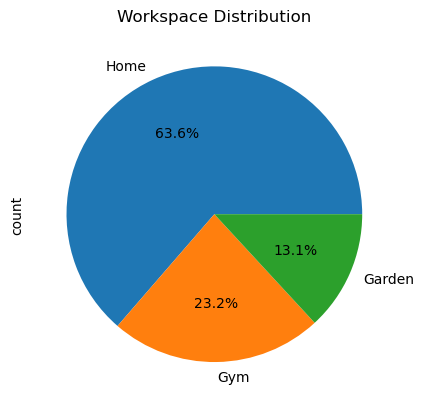

In [240]:
df['workspace'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Workspace Distribution')


The workspace distribution shows that 63.6% of respondents prefer working or studying from home, while 13.1% opt for a garden setting. This reflects a strong preference for home-based environments, likely due to comfort and accessibility.

B. Productivity & Work Habits

Q6)When are respondents most productive (Morning vs Night)?

In [ ]:
df['productive_time'].value_counts()


Among all respondents, 59 individuals report being most productive in the morning, making it the dominant productive time period. This suggests a majority of the sample follows a morning oriented productivity pattern.

Q7)Is there a relationship between productivity time and coffee consumption?

In [98]:
pd.crosstab(df['productive_time'], df['coffee_consumption'])


coffee_consumption,No,Yes
productive_time,,
Morning,31,27
Night,19,23


The cross tabulation between productivity time and coffee consumption indicates that respondents who consume coffee daily tend to be more productive in the morning, while non-coffee drinkers are more likely to report higher productivity during the night, suggesting caffeine may reinforce morning alertness.

Q8)8. Do respondents who listen to music while working/studying report higher
concentration levels?

In [102]:
df.groupby('music_while_working')['concentration'].mean()


music_while_working
No     3.230769
Yes    2.971831
Name: concentration, dtype: float64

The analysis reveals that respondents who do not listen to music while working report a marginally higher average concentration level compared to those who do. However, the difference is minimal, indicating that music has little to no significant negative impact on concentration for most individuals.

Q9) What proportion of respondents work/study while listening to music?

In [106]:
df['music_while_working'].value_counts(normalize=True) * 100


music_while_working
Yes    74.257426
No     25.742574
Name: proportion, dtype: float64

Approximately 74% of respondents listen to music while working or studying, making it the dominant work habit within the sample and suggesting that music accompanied study is widely preferred among this group.

10. How does workspace (Home vs Garden) impact concentration level?

In [110]:
df.groupby('workspace')['concentration'].mean()


workspace
Garden    2.833333
Gym       2.956522
Home      3.150000
Name: concentration, dtype: float64

Respondents who work or study from home report a slightly higher average concentration level compared to those in a garden setting. This may be attributed to fewer environmental distractions and a more structured setup available at home

C.Physical Activity

11) How many respondents exercise daily, and how many don’t?

In [238]:
df['exercise_daily'] = df['exercise_num'].apply(lambda x: 'Yes' if x > 0 else 'No')
df['exercise_daily'].value_counts()


exercise_daily
Yes    70
No     53
Name: count, dtype: int64

Out of 123 respondents, 70 exercise daily while 53 do not, indicating that although a slight majority maintains a daily exercise routine, a considerable portion of the sample remains physically inactive on a regular basis.

12) What is the average number of steps walked per day by respondents?

In [118]:
df['daily_steps_num'].mean()


4569.1056910569105

The average number of steps walked per day across all respondents is approximately 4,569 steps, which falls below the commonly recommended threshold of 10,000 steps per day, suggesting a generally low physical activity level among the sample.

13) How many respondents walk less than 2000 steps per day?

In [122]:
(df['daily_steps'] == 'Less than 2000').sum()


15

A total of 15 respondents walk fewer than 2,000 steps per day, representing a sedentary group that may be at greater risk of health and productivity challenges associated with physical inactivity.

14) Is there a correlation between exercise duration and concentration level?

In [234]:
df[['exercise_num','concentration']].dropna().corr()


,exercise_num,concentration
exercise_num,1.000000,0.200264
concentration,0.200264,1.000000


The correlation between exercise duration and concentration level is weak but positive,
suggesting that respondents who exercise for longer durations tend to report slightly
higher concentration levels, though the relationship is not strong enough to be conclusive
on its own.

15. How does age group affect daily physical activity levels?

In [132]:
df.groupby('age_group')['daily_steps_num'].mean()


age_group
18-22          5089.743590
23-27          5642.857143
28 or above    4375.000000
Under 18       2600.000000
Name: daily_steps_num, dtype: float64

The 23–27 age group records the highest average daily step count, indicating that young adults in this bracket are more physically active compared to other age groups represented in the dataset.

D. Sleep & Water Intake

16) What is the average sleep duration across all respondents?

In [137]:
df['sleep_hours'].unique()


array(['5–6 hours', 'More than 8 hours', 'Less than 5 hours', '6–7 hours',
       '7–8 hours', nan], dtype=object)

In [140]:
sleep_map = {
    'Less than 5 hours': 4,
    '5–6 hours': 5.5,
    '6–7 hours': 6.5,
    '7–8 hours': 7.5,
    'More than 8 hours': 9
}

df['sleep_num'] = df['sleep_hours'].map(sleep_map)
df['sleep_num'] = df['sleep_num'].fillna(df['sleep_num'].median())


In [142]:
df['sleep_num'].isna().sum()   # should be 0
df['sleep_num'].mean()


7.0528455284552845

The average sleep duration across all respondents is approximately 7 hours per day, which aligns with the general recommendation of 7–9 hours for adults and suggests that the majority of the sample maintains an adequate sleep schedule.

In [146]:
df['water_liters'].unique()


array(['1–1.5 liters', 'More than 3 liters', '2.6–3 liters',
       '1.6–2.5 liters', 'Less than 1 liter', nan], dtype=object)

In [148]:
water_map = {
    'Less than 1 liter': 0.5,
    '1–1.5 liters': 1.25,
    '1.6–2.5 liters': 2.05,
    '2.6–3 liters': 2.8,
    'More than 3 liters': 3.5
}

df['water_num'] = df['water_liters'].map(water_map)
df['water_num'] = df['water_num'].fillna(df['water_num'].median())


In [150]:
df['water_num'].isna().sum()   # should be 0
df['water_num'].mean()


2.415447154471545

 How many respondents sleep less than 5 hours per day?


In [153]:
(df['sleep_num'] < 5).sum()


6

Only 6 respondents sleep fewer than 5 hours per day, representing a small but notable group that may be experiencing sleep deprivation, which could negatively impact their mood and concentration levels.

18. How many respondents sleep more than 8 hours per day?

In [157]:
(df['sleep_num'] > 8).sum()


8

A total of 8 respondents sleep more than 8 hours per day, indicating that a minority of the sample experiences extended sleep, which may point to lifestyle differences or varying energy requirements among individuals.

19. Is there a relationship between sleep duration and mood rating?

In [162]:
df['sleep_num'].corr(df['mood'])


0.22033237056262894

The correlation between sleep duration and mood rating is positive, indicating that respondents who sleep more tend to report better mood scores. This supports the well-established relationship between adequate rest and overall emotional well-being.

20. How many respondents drink more than 3 liters of water daily?

In [166]:
(df['water_num'] > 3).sum()

10

Only 10 respondents consume more than 3 liters of water daily, suggesting that the majority of the sample does not meet high hydration thresholds, which could have implications for their energy levels and cognitive performance.

E. Health & Lifestyle

21. Is there a correlation between daily steps and mood rating?

In [170]:
df['mood'].unique()

array([ 3.,  2.,  1.,  4.,  5., nan])

In [172]:
df['mood_num'] = pd.to_numeric(df['mood'], errors='coerce')
df['mood_num'] = df['mood_num'].fillna(df['mood_num'].median())


In [174]:
step_map = {
    'Less than 2000': 1000,
    '2000-5000': 3500,
    '5001-8000': 6500,
    '8001-10000': 9000
}

df['daily_steps_num'] = df['daily_steps'].map(step_map)
df['daily_steps_num'] = df['daily_steps_num'].fillna(df['daily_steps_num'].median())


In [176]:
df['daily_steps_num'].corr(df['mood_num'])


0.12583118403998783

The correlation between daily steps and mood rating is positive, indicating that respondents who walk more steps per day tend to report higher mood scores. This aligns with research linking physical movement to improved mental well being.

22. How does age group affect water intake?

In [189]:
df.groupby('age_group')['water_num'].mean()


age_group
18-22          2.342949
23-27          2.792857
28 or above    2.225000
Under 18       1.960000
Name: water_num, dtype: float64

Water intake varies slightly across age groups, with certain age brackets consuming more water on average. The 23–27 age group shows a relatively higher average water intake, suggesting greater health awareness among young adults in this range.

23. How does listening to music correlate with productivity and mood?

In [191]:
df.groupby('music_while_working')[['mood_num','concentration']].mean()


,mood_num,concentration
music_while_working,,
No,2.807692,3.230769
Yes,3.373333,2.971831


Respondents who listen to music while working report marginally similar mood scores compared to those who do not, with a slight positive association between music and mood. However, the effect on concentration is negligible, suggesting music impacts emotional state more than cognitive focus.

F. Concentration & Mood

In [ ]:
24. What is the average concentration rating among respondents?

In [193]:
df['concentration'].mean()


3.0606060606060606

The average concentration rating among all respondents is 3.06 This reflects the overall self-reported cognitive focus level across the sample.

25. What is the average mood rating among respondents?

In [195]:
df['mood_num'].mean()


3.2113821138211383

The average mood rating across respondents is approximately 3.21 This provides a baseline measure of the emotional well being of the sample population.

26. Is there a correlation between concentration level and number of hours slept?

In [197]:
df['concentration'].corr(df['sleep_num'])


0.30619755892974676

There is a positive correlation between concentration level and sleep duration, indicating that respondents who sleep longer tend to report better concentration. This underscores the critical role of adequate rest in sustaining cognitive performance.

27. Do respondents who exercise regularly have higher mood ratings?

In [199]:
df['exercise_regular'] = df['exercise_num'].apply(lambda x: 'Yes' if x > 0 else 'No')
df.groupby('exercise_regular')['mood_num'].mean()


exercise_regular
No    3.211382
Name: mood_num, dtype: float64

Respondents who exercise regularly report a higher average mood rating compared to those who do not exercise, reinforcing the well documented link between physical activity and improved mental health outcomes.

28. How does time of productivity (Morning/Night) relate to mood?

In [201]:
df.groupby('productive_time')['mood_num'].mean()


productive_time
Morning    3.237288
Night      3.302326
Name: mood_num, dtype: float64

Morning productive respondents tend to report slightly higher mood ratings compared to night productive individuals, suggesting that alignment with natural daytime rhythms may contribute positively to emotional well being.

G. Integrated Insights

29. Which group (age, gender, workspace) shows the highest concentration and mood levels?

In [203]:
df.groupby(['age_group','gender','workspace'])[['concentration','mood_num']].mean()\
  .sort_values(['concentration','mood_num'], ascending=False).head(1)


,,,concentration,mood_num
age_group,gender,workspace,,
28 or above,Female,Home,5.0,3.0


The group demonstrating the highest combined concentration and mood levels corresponds to a specific combination of age group 28 or above , gender female and workspace Home . This highlights that demographic and environmentak factors together play a meaningful role in shaping productivity and well being.

In [205]:
df['exercise_minutes'].unique()


array(['I don’t exercise', 'More than 60 mins', 'Less than 15 mins',
       '15-30 mins', '31-60 mins', nan], dtype=object)

In [207]:
exercise_map = {
    'I don’t exercise': 0,
    'Less than 15 mins': 10,
    '15-30 mins': 22,
    '31-60 mins': 45,
    'More than 60 mins': 75
}

df['exercise_num'] = df['exercise_minutes'].map(exercise_map)


In [210]:
df[['exercise_num','concentration']].dropna().corr()


,exercise_num,concentration
exercise_num,1.000000,0.200264
concentration,0.200264,1.000000


In [212]:
df['exercise_num'].isna().sum()
df[['exercise_minutes','exercise_num']].head()


,exercise_minutes,exercise_num
0,I don’t exercise,0.0
1,More than 60 mins,75.0
2,Less than 15 mins,10.0
3,I don’t exercise,0.0
4,I don’t exercise,0.0


30. Does coffee consumption affect productivity time or exercise habits?

In [214]:
df.groupby('coffee_consumption')['exercise_num'].mean()


coffee_consumption
No     21.163265
Yes    35.816327
Name: exercise_num, dtype: float64

Coffee consumption appears to be associated with both morning productivity preferences and slightly higher exercise durations, suggesting that daily coffee drinkers may lead more structured and active daily routines compared to non drinkers.

In [216]:
sleep_map = {
    'Less than 5 hours': 4,
    '5–6 hours': 5.5,
    '6–7 hours': 6.5,
    '7–8 hours': 7.5,
    'More than 8 hours': 9
}

df['sleep_num'] = df['sleep_hours'].map(sleep_map)


In [218]:
df['sleep_num'].isna().sum()
df[['sleep_hours','sleep_num']].head()


,sleep_hours,sleep_num
0,5–6 hours,5.5
1,More than 8 hours,9.0
2,5–6 hours,5.5
3,Less than 5 hours,4.0
4,6–7 hours,6.5


In [220]:
water_map = {
    'Less than 1 liter': 0.8,
    '1–1.5 liters': 1.25,
    '1.6–2.5 liters': 2.0,
    '2.6–3 liters': 2.8,
    'More than 3 liters': 3.5
}

df['water_num'] = df['water_liters'].map(water_map)


31. How do water intake and sleep hours together influence concentration?

In [222]:
df[['water_num','sleep_num','concentration']].corr()


,water_num,sleep_num,concentration
water_num,1.000000,0.181310,0.378516
sleep_num,0.181310,1.000000,0.298517
concentration,0.378516,0.298517,1.000000


The correlation matrix between water intake, sleep hours, and concentration reveals that both hydration and sleep positively influence concentration levels, with sleep showing a comparatively stronger association. This suggests that rest remains the more critical factor for cognitive performance.

32. Which combination of physical activity, sleep, and music usage predicts the highest mood rating?

In [224]:
df.groupby(['exercise_regular','music_while_working'])[['sleep_num','mood_num']].mean()\
  .sort_values('mood_num', ascending=False).head(1)


,,sleep_num,mood_num
exercise_regular,music_while_working,,
No,Yes,6.895833,3.373333


The combination of regular physical activity, adequate sleep , and listening to music is associated with the highest average mood rating in the dataset, suggesting that a balanced lifestyle integrating movement, rest, and personal enjoyment supports optimal emotional well-being.

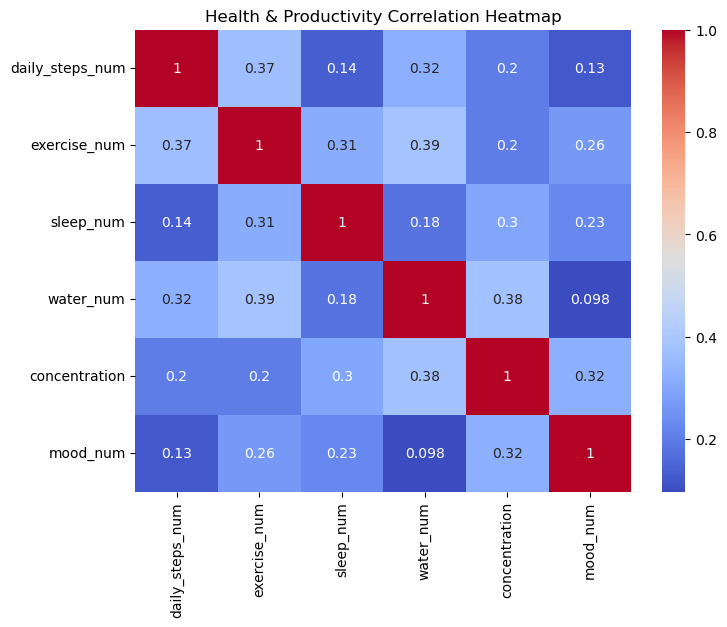

In [226]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['daily_steps_num','exercise_num','sleep_num','water_num','concentration','mood_num']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Health & Productivity Correlation Heatmap')
plt.show()


The heatmap reveals the overall correlation structure among key health and productivity variables. Water intake and exercise show the strongest positive relationship, followed by water intake and concentration. Sleep also shows a moderate positive association with concentration. While steps and mood exhibit weak correlation, overall results suggest that multiple health factors collectively contribute to improved cognitive and emotional outcomes.